# Brief 2 - Analyse, integration et retrocompatibilite

Ce notebook centralise l'analyse exploratoire, les choix de nettoyage, la compatibilite multi-CSV, l'analyse ethique et les resultats d'entrainement finaux.

## Objectifs

- analyser `data/raw_data.csv` et `data/raw_data_2.csv`
- montrer la retrocompatibilite de l'import
- justifier les traitements de nettoyage
- documenter l'evolution du schema, le choix ethique des features et les resultats du modele

In [19]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'scripts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from scripts.import_raw_data import clean_raw_dataframe, load_raw_dataframes

ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 200)

In [20]:
raw_df, source_metadata = load_raw_dataframes()
cleaned_df, cleaning_stats = clean_raw_dataframe(raw_df)
current_metrics = json.loads((ARTIFACTS_DIR / 'metrics.json').read_text(encoding='utf-8'))
outlier_summary = json.loads((ARTIFACTS_DIR / 'outlier_summary.json').read_text(encoding='utf-8'))
source_metadata

{'source_files': ['raw_data.csv', 'raw_data_2.csv'],
 'rows_by_file': {'raw_data.csv': 10000, 'raw_data_2.csv': 10000},
 'added_optional_columns': {'raw_data.csv': ['orientation_sexuelle',
   'quotient_caf',
   'nb_enfants'],
  'raw_data_2.csv': []},
 'total_rows': 20000}

## 1. Retrocompatibilite de l'import

Le pipeline charge deux fichiers :

- `data/raw_data.csv` : ancien format
- `data/raw_data_2.csv` : format enrichi avec `orientation_sexuelle`, `nb_enfants` et `quotient_caf`

Quand une colonne n'existe pas dans un CSV, elle est ajoutee avec `NULL` (`pd.NA`) puis la base gere ces valeurs comme des champs optionnels.

In [21]:
pd.DataFrame({
    'source_file': source_metadata['source_files'],
    'rows': [source_metadata['rows_by_file'][name] for name in source_metadata['source_files']],
    'added_missing_columns': [', '.join(source_metadata['added_optional_columns'][name]) or 'none' for name in source_metadata['source_files']],
})

,source_file,rows,added_missing_columns
0,raw_data.csv,10000,"orientation_sexuelle, quotient_caf, nb_enfants"
1,raw_data_2.csv,10000,none


## 2. Vue d'ensemble des donnees brutes

In [22]:
print(f'Nombre de lignes brutes concatenees: {len(raw_df)}')
print(f'Nombre de colonnes harmonisees: {len(raw_df.columns)}')
raw_df.head()

Nombre de lignes brutes concatenees: 20000
Nombre de colonnes harmonisees: 23


,nom,prenom,age,taille,poids,sexe,sport_licence,niveau_etude,region,smoker,nationalité_francaise,revenu_estime_mois,situation_familiale,historique_credits,risque_personnel,date_creation_compte,score_credit,loyer_mensuel,montant_pret,orientation_sexuelle,quotient_caf,nb_enfants,source_file
0,Foster,Steven,19,175.0,62.5,H,non,bac,Île-de-France,oui,oui,4958,veuf,NaN,0.19,2021-04-04,NaN,NaN,500.000000,<NA>,<NA>,<NA>,raw_data.csv
1,Tapia,Todd,31,190.0,63.5,H,oui,bac+2,Corse,non,oui,3001,veuf,NaN,0.93,2023-03-19,NaN,1270.84,786.595929,<NA>,<NA>,<NA>,raw_data.csv
2,Hardy,Michelle,68,174.6,66.5,H,oui,doctorat,Auvergne-Rhône-Alpes,oui,oui,3758,NaN,NaN,0.68,2024-08-27,576.0,NaN,29093.676397,<NA>,<NA>,<NA>,raw_data.csv
3,Newton,Kenneth,50,187.1,106.8,H,oui,master,Occitanie,non,non,3967,marié,NaN,0.68,2022-03-18,NaN,10000.00,7823.303925,<NA>,<NA>,<NA>,raw_data.csv
4,Davila,Kathleen,42,169.7,63.4,H,oui,master,Provence-Alpes-Côte d’Azur,non,non,2091,NaN,3.0,0.92,2020-10-17,NaN,5000.00,500.000000,<NA>,<NA>,<NA>,raw_data.csv


In [23]:
quality = pd.DataFrame({
    'missing_count': raw_df.isna().sum(),
    'missing_ratio_pct': (raw_df.isna().mean() * 100).round(2),
    'dtype': raw_df.dtypes.astype(str),
}).sort_values('missing_ratio_pct', ascending=False)
quality

,missing_count,missing_ratio_pct,dtype
historique_credits,10616,53.08,float64
score_credit,10512,52.56,float64
nb_enfants,10000,50.00,object
quotient_caf,10000,50.00,object
orientation_sexuelle,10000,50.00,object
loyer_mensuel,5942,29.71,float64
situation_familiale,4910,24.55,str
nom,0,0.00,str
montant_pret,0,0.00,float64
date_creation_compte,0,0.00,str


## 3. Visualisations pour justifier le nettoyage

Les visualisations suivantes servent a objectiver les valeurs manquantes, les distributions et les valeurs aberrantes les plus importantes.

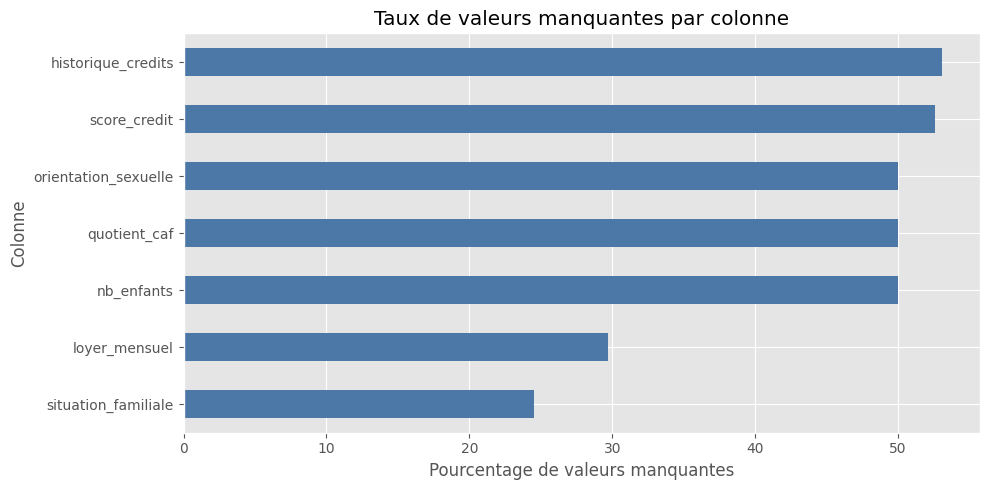

In [24]:
quality_to_plot = quality[quality['missing_count'] > 0].sort_values('missing_ratio_pct')
ax = quality_to_plot['missing_ratio_pct'].plot(kind='barh', figsize=(10, 5), color='#4C78A8')
ax.set_title('Taux de valeurs manquantes par colonne')
ax.set_xlabel('Pourcentage de valeurs manquantes')
ax.set_ylabel('Colonne')
plt.tight_layout()
plt.show()

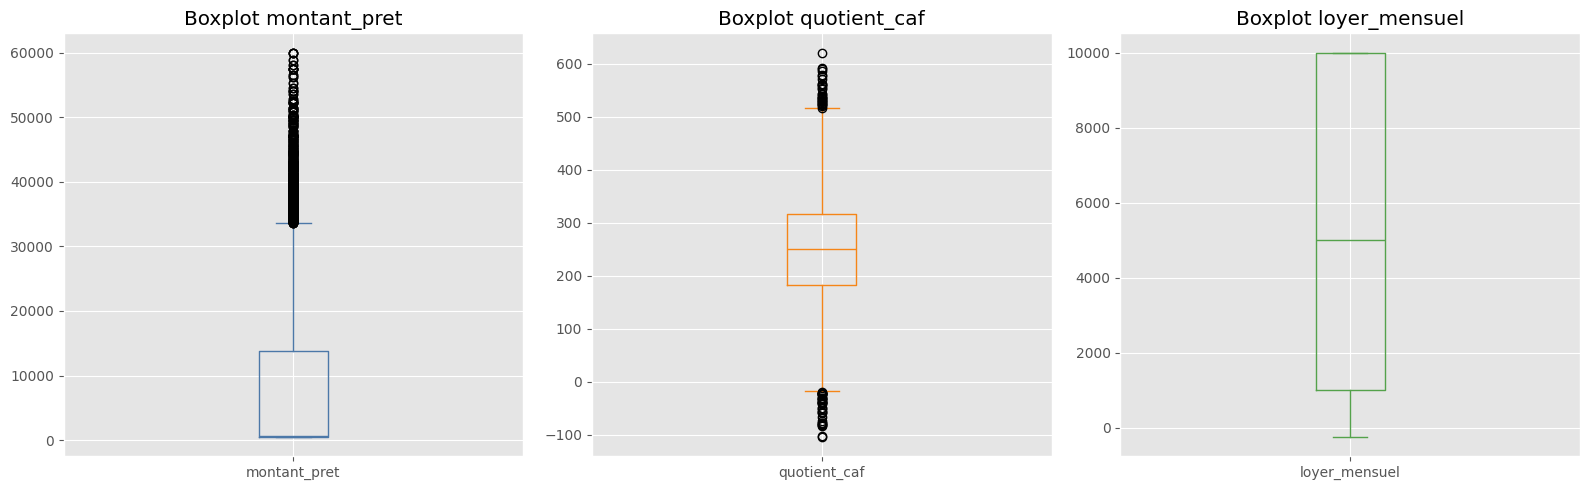

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pd.to_numeric(raw_df['montant_pret'], errors='coerce').plot(kind='box', ax=axes[0], color='#4C78A8')
axes[0].set_title('Boxplot montant_pret')
pd.to_numeric(raw_df['quotient_caf'], errors='coerce').plot(kind='box', ax=axes[1], color='#F58518')
axes[1].set_title('Boxplot quotient_caf')
pd.to_numeric(raw_df['loyer_mensuel'], errors='coerce').plot(kind='box', ax=axes[2], color='#54A24B')
axes[2].set_title('Boxplot loyer_mensuel')
plt.tight_layout()
plt.show()

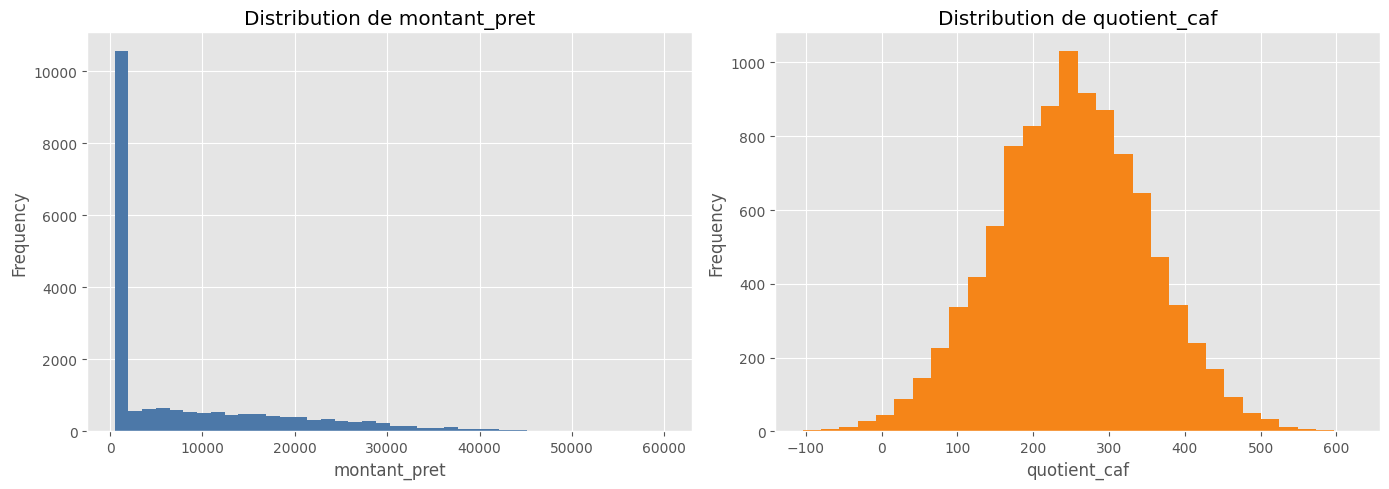

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.to_numeric(raw_df['montant_pret'], errors='coerce').plot(kind='hist', bins=40, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribution de montant_pret')
axes[0].set_xlabel('montant_pret')
pd.to_numeric(raw_df['quotient_caf'], errors='coerce').plot(kind='hist', bins=30, ax=axes[1], color='#F58518')
axes[1].set_title('Distribution de quotient_caf')
axes[1].set_xlabel('quotient_caf')
plt.tight_layout()
plt.show()

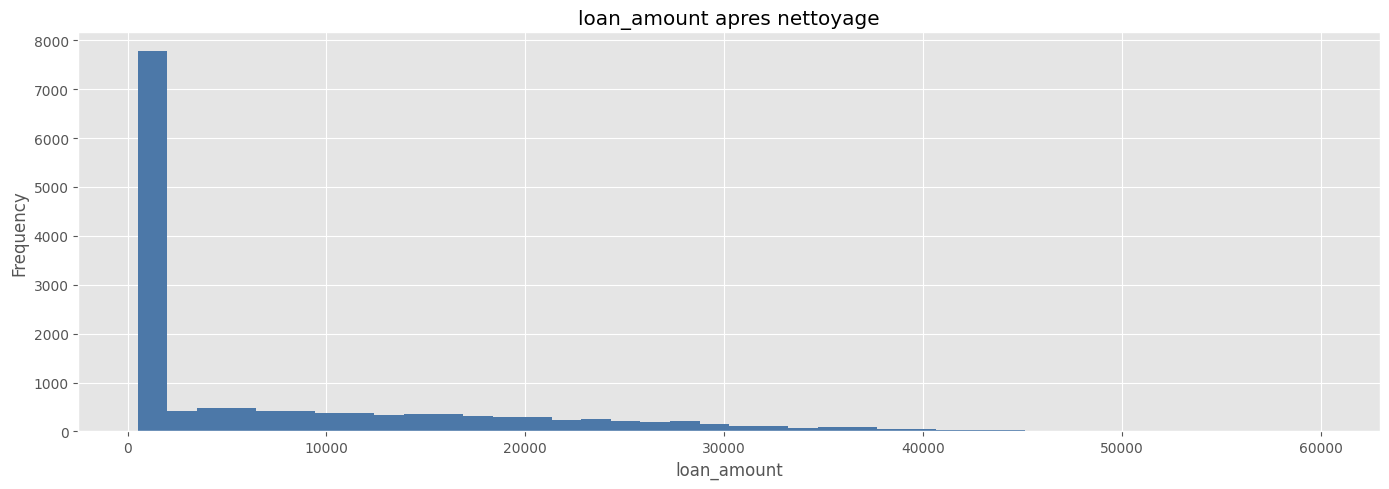

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(14, 5))
pd.to_numeric(cleaned_df['loan_amount'], errors='coerce').plot(kind='hist', bins=40, ax=axes, color='#4C78A8')
axes.set_title('loan_amount apres nettoyage')
axes.set_xlabel('loan_amount')
plt.tight_layout()
plt.show()

## 4. Anomalies detectees

In [28]:
issues = {
    'duplicates_full_rows': int(raw_df.duplicated().sum()),
    'negative_nb_enfants': int((pd.to_numeric(raw_df['nb_enfants'], errors='coerce') < 0).sum()),
    'negative_quotient_caf': int((pd.to_numeric(raw_df['quotient_caf'], errors='coerce') < 0).sum()),
    'negative_loyer_mensuel': int((pd.to_numeric(raw_df['loyer_mensuel'], errors='coerce') < 0).sum()),
    'sexual_orientation_values': sorted(raw_df['orientation_sexuelle'].dropna().astype(str).str.strip().unique().tolist()),
}
issues

{'duplicates_full_rows': 0,
 'negative_nb_enfants': 252,
 'negative_quotient_caf': 66,
 'negative_loyer_mensuel': 16,
 'sexual_orientation_values': ['het', 'hom']}

Les principales decisions de nettoyage sont les suivantes :

- imputation mediane pour certaines colonnes numeriques presentes mais incompletes pendant l'ingestion
- imputation par mode pour `situation_familiale`
- borne basse a `0` pour `nb_enfants`
- borne basse a `0` pour `quotient_caf`
- borne basse a `0` pour `loyer_mensuel`
- conservation des colonnes absentes comme `NULL` pour rester compatible avec plusieurs versions de fichiers

## 5. Resultat apres nettoyage

In [29]:
print(f'Lignes avant nettoyage: {cleaning_stats["initial_rows"]}')
print(f'Lignes apres filtre missing ratio: {cleaning_stats["rows_after_missing_ratio_filter"]}')
print(f'Lignes apres filtre colonnes essentielles: {cleaning_stats["rows_after_essential_filter"]}')
print(f'Lignes apres filtre cible: {cleaning_stats["rows_after_target_filter"]}')
print(f'Lignes retirees: {cleaning_stats["rows_removed"]}')
cleaning_stats

Lignes avant nettoyage: 20000
Lignes apres filtre missing ratio: 14723
Lignes apres filtre colonnes essentielles: 14723
Lignes apres filtre cible: 14723
Lignes retirees: 5277


{'initial_rows': 20000,
 'rows_after_missing_ratio_filter': 14723,
 'rows_after_essential_filter': 14723,
 'rows_after_target_filter': 14723,
 'rows_removed': 5277,
 'imputed_numeric': {'historique_credits': 6672,
  'score_credit': 6549,
  'loyer_mensuel': 3449,
  'quotient_caf': 4723,
  'nb_enfants': 4723},
 'imputed_non_numeric': {'situation_familiale': 2859,
  'orientation_sexuelle': 4723},
 'initial_target_stats': {'count': 20000,
  'min': 500.0,
  'median': 646.3060565186204,
  'max': 60000.0},
 'cleaned_target_stats': {'count': 14723,
  'min': 500.0,
  'median': 643.8541157096249,
  'max': 60000.0}}

In [30]:
cleaned_df[['family_status', 'credit_history_count', 'credit_score', 'monthly_rent', 'sexual_orientation', 'caf_quotient', 'child_count']].isna().sum()

family_status           0
credit_history_count    0
credit_score            0
monthly_rent            0
sexual_orientation      0
caf_quotient            0
child_count             0
dtype: int64

## 6. Schema relationnel et flux de donnees

Le schema reste organise autour de deux entites : `clients` et `loan_informations`. Les nouvelles colonnes `sexual_orientation`, `caf_quotient` et `child_count` sont rattachees a `clients` car elles decrivent le profil client et non un pret particulier.

Flux : lecture CSV -> harmonisation des colonnes manquantes -> nettoyage -> renommage CSV vers SQLAlchemy -> insertion en base -> exposition partielle via API -> selection des variables d'entrainement.

## 7. Choix ethiques et preprocessing ML

Variables retenues pour le modele : `age`, `estimated_monthly_income`, `credit_history_count`, `personal_risk_score`, `credit_score`, `monthly_rent`, `caf_quotient`.

Variables exclues : `sexual_orientation`, les identifiants, et les variables socio-demographiques non retenues pour le besoin metier.

Le pipeline ML final applique :

- `KNNImputer(n_neighbors=5, weights="distance")` sur les variables numeriques
- `StandardScaler`
- transformation de la cible avec `log1p(loan_amount)`
- retour a l'echelle reelle avec `expm1` pour evaluer les predictions en euros

### Pourquoi `log1p` ?

`log1p(x)` signifie `log(1 + x)`. Cette transformation compresse les grandes valeurs de `loan_amount`, reduit l'effet des montants extremes et facilite l'apprentissage sur une cible tres asymetrique. Les predictions sont ensuite reconverties avec `expm1`.

## 8. Outliers

In [31]:
pd.DataFrame(outlier_summary).T[['q1', 'q3', 'lower_bound', 'upper_bound', 'outlier_count']]

,q1,q3,lower_bound,upper_bound,outlier_count
age,32.00,61.000000,-11.500000,104.500000,0.0
estimated_monthly_income,1674.00,3291.000000,-751.500000,5716.500000,41.0
credit_history_count,2.00,3.000000,0.500000,4.500000,2580.0
personal_risk_score,0.25,0.760000,-0.515000,1.525000,0.0
credit_score,549.00,600.000000,472.500000,676.500000,5000.0
monthly_rent,1532.39,10000.000000,-11169.025000,22701.415000,0.0
caf_quotient,216.20,283.400000,115.400000,384.200000,1790.0
loan_amount,500.00,13779.982189,-19419.973283,33699.955472,506.0


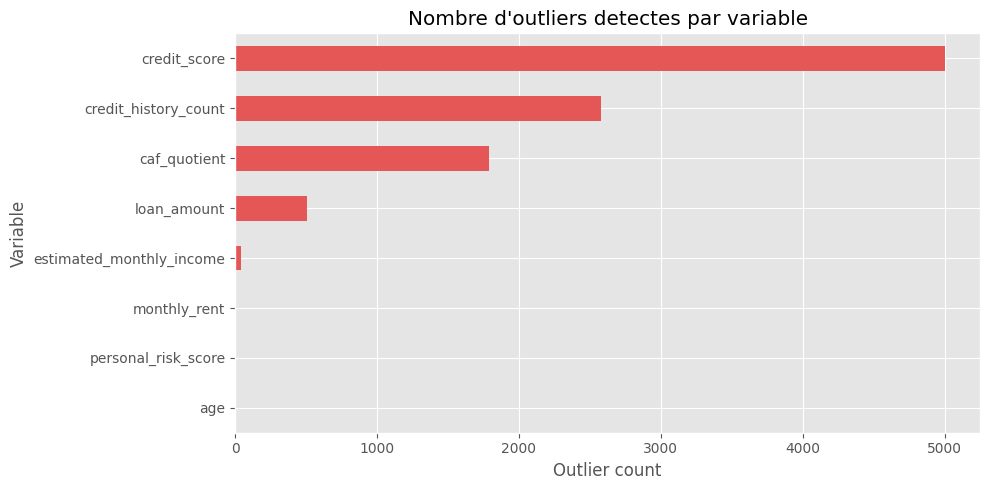

In [32]:
pd.DataFrame(outlier_summary).T['outlier_count'].sort_values().plot(kind='barh', figsize=(10, 5), color='#E45756')
plt.title('Nombre d\'outliers detectes par variable')
plt.xlabel('Outlier count')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

Les variables les plus sensibles aux outliers sont `loan_amount`, `caf_quotient`, `credit_score` et `credit_history_count`. Les deux dernieres doivent etre interpretees avec prudence car il s'agit de variables discretes ou bornees.

## 9. Resultats d'entrainement avant / apres

In [33]:
previous_metrics = {
    'train_loss': 109870424.0,
    'val_loss': 104136704.0,
    'test_loss': 104993768.0,
    'test_mae': 8209.19140625,
}
comparison = pd.DataFrame({
    'before_log1p_knn': pd.Series(previous_metrics),
    'after_log1p_knn': pd.Series(current_metrics),
})
comparison

,before_log1p_knn,after_log1p_knn
imputer,NaN,"KNNImputer(n_neighbors=5, weights='distance')"
prediction_count,NaN,2209
target_transform,NaN,log1p
test_loss,1.049938e+08,131822422.414187
test_mae,8.209191e+03,7169.41239
train_loss,1.098704e+08,2.640955
val_loss,1.041367e+08,2.705809


Interpretation rapide :

- le `test_mae` passe d'environ `8209` a `7169`, ce qui constitue une amelioration visible
- le `test_loss` reste eleve, ce qui montre que les grosses erreurs sur certains montants extremes existent encore
- `train_loss` et `val_loss` sont maintenant dans l'espace `log1p`, donc ils ne sont pas directement comparables aux anciennes losses brutes

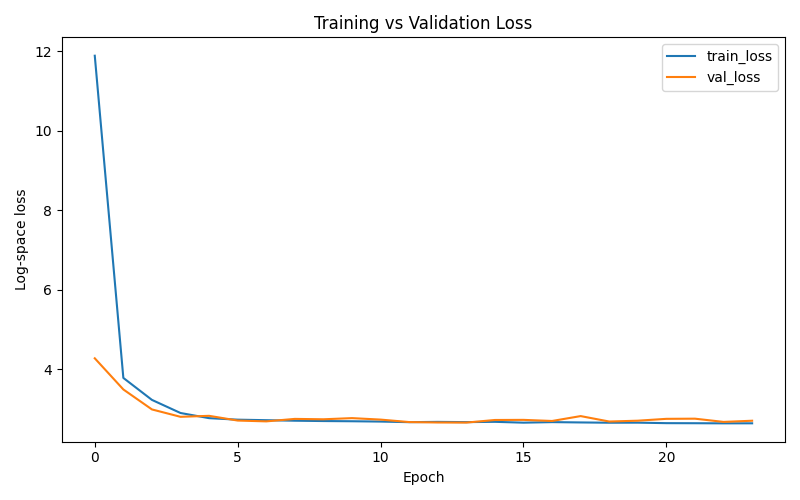

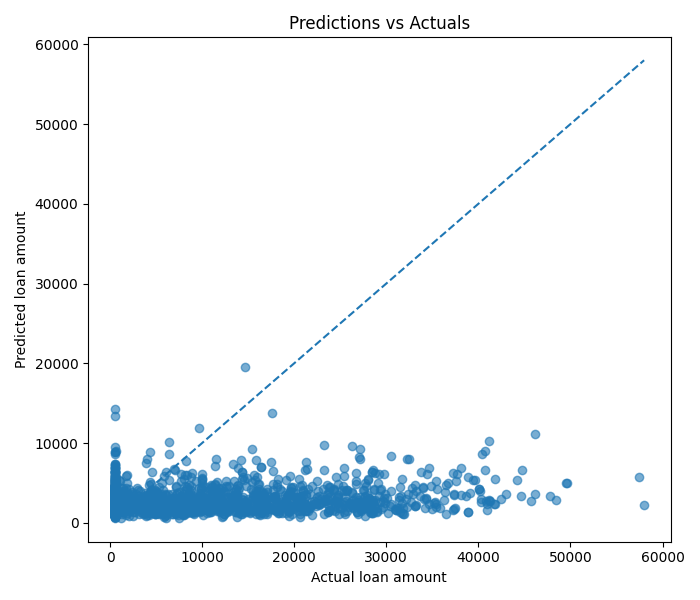

In [34]:
display(Image(filename=str(ARTIFACTS_DIR / 'loss_curve.png')))
display(Image(filename=str(ARTIFACTS_DIR / 'predictions_vs_actuals.png')))